<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Project 1: Cardiac Patient Monitoring System
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Project Scope & Clinical Mission:</b>
The Cardiac Patient Monitoring System implements an end-to-end supervised and unsupervised diagnostic pipeline. We analyze clinical, demographic, and electrocardiogram (ECG) exercise stress-testing markers to predict acute cardiac risk (`HeartDisease`: $0 = \text{Normal}$, $1 = \text{Heart Disease Present}$).

</blockquote>

---

## <span style="color: #309c42ff">1.1 Environment Setup & Dataset Schema Audit</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We establish deterministic random seeds (`seed = 42`) and load the patient cohort ($N = 918$) from `../Data/heart.csv`. The feature space spans 11 physiological attributes alongside the ground-truth diagnostic label.

</blockquote>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../Data/heart.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())
df.info()


Dataset Shape: 918 rows, 12 columns



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## <span style="color: #309c42ff">1.2 Data Quality Treatment & Anomaly Auditing</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Clinical Anomaly Screening:</b>
1. <b>Resting Blood Pressure (`RestingBP == 0`):</b> $0\text{ mm Hg}$ is incompatible with life in an ambulatory patient ($n = 1$); replaced with `np.nan`.
2. <b>Serum Cholesterol (`Cholesterol == 0`):</b> 172 records ($18.7\%$) report $0\text{ mg/dl}$, reflecting structural non-measurement at the Hungarian recording center; replaced with `np.nan`.
3. <b>Leak-Free Resolution:</b> Imputed using median statistics derived strictly from training folds.

</blockquote>


In [2]:
print("Duplicate rows count:", df.duplicated().sum())
print("\nExplicit missing values (isnull):")
print(df.isnull().sum())

zero_bp = (df['RestingBP'] == 0).sum()
zero_chol = (df['Cholesterol'] == 0).sum()

print("\n--- Physiologically Invalid Zero Values ---")
print(f"\nRestingBP zero count: {zero_bp} ({zero_bp / len(df) * 100:.2f}%)")
print(f"Cholesterol zero count: {zero_chol} ({zero_chol / len(df) * 100:.2f}%)")

categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
target_variable = 'HeartDisease'

print("\nCategorical Features:", categorical_features)
print("Numerical Features:  ", numerical_features)
print("Target Variable:     ", target_variable)


Duplicate rows count: 0

Explicit missing values (isnull):
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

--- Physiologically Invalid Zero Values ---

RestingBP zero count: 1 (0.11%)
Cholesterol zero count: 172 (18.74%)

Categorical Features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical Features:   ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Target Variable:      HeartDisease


## <span style="color: #309c42ff">1.3 Exploratory Data Analysis & Clinical Statistics</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We conduct univariate distribution checks, Interquartile Range (IQR) outlier audits, bivariate cross-tabulations, and correlation analysis to uncover physiological patterns governing coronary disease.

</blockquote>


In [3]:
desc_stats = df[numerical_features].describe().T
desc_stats['variance'] = df[numerical_features].var()
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['median'] = df[numerical_features].median()

desc_stats = desc_stats[['count', 'mean', 'median', 'std', 'variance', 'min', '25%', '75%', 'IQR', 'max']]
print("--- Descriptive Statistics Table ---")
display(desc_stats)

target_summary = pd.DataFrame({
    'Count': df['HeartDisease'].value_counts(),
    'Percentage (%)': df['HeartDisease'].value_counts(normalize=True) * 100
})
target_summary.index = ['Heart Disease (1)', 'Normal (0)']
print("\n--- Target Class Balance ---")
display(target_summary)


--- Descriptive Statistics Table ---


,count,mean,median,std,variance,min,25%,75%,IQR,max
Age,918.0,53.510893,54.0,9.432617,88.974254,28.0,47.00,60.0,13.00,77.0
RestingBP,918.0,132.396514,130.0,18.514154,342.773903,0.0,120.00,140.0,20.00,200.0
Cholesterol,918.0,198.799564,223.0,109.384145,11964.891079,0.0,173.25,267.0,93.75,603.0
MaxHR,918.0,136.809368,138.0,25.460334,648.228614,60.0,120.00,156.0,36.00,202.0
Oldpeak,918.0,0.887364,0.6,1.066570,1.137572,-2.6,0.00,1.5,1.50,6.2



--- Target Class Balance ---


,Count,Percentage (%)
Heart Disease (1),508,55.337691
Normal (0),410,44.662309


### <span style="color: #309c42ff"> 1. Univariate Categorical distributions</span>



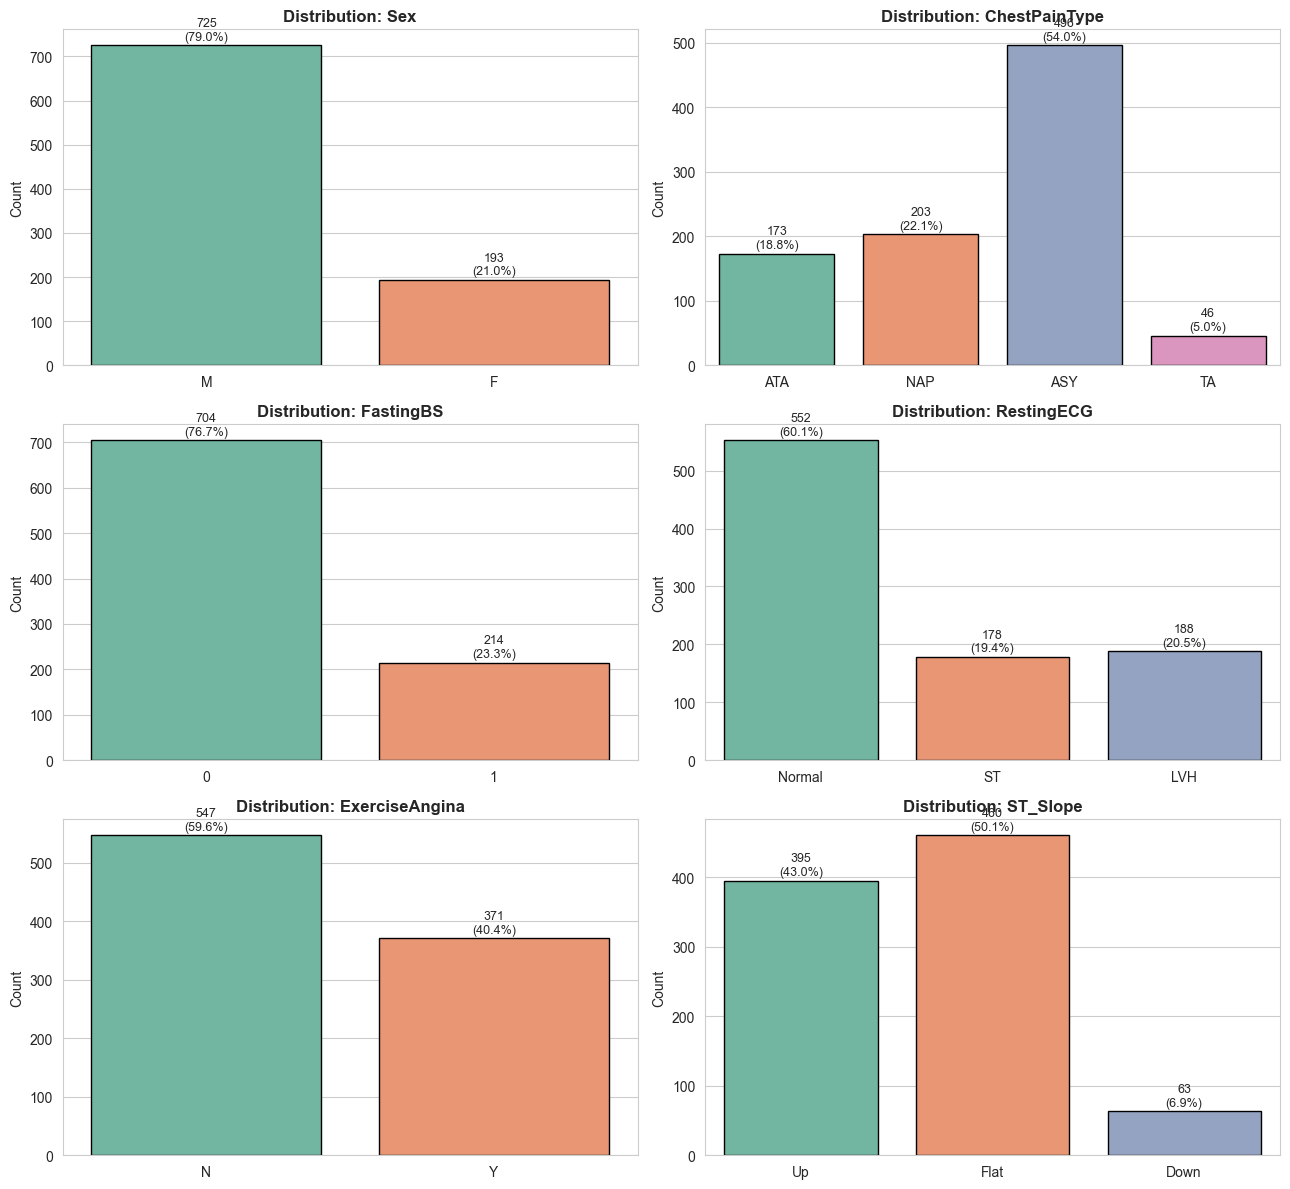

In [4]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue=col,
        legend=False,
        ax=axes[i], 
        palette='Set2',
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    
    total = len(df[col])
    for p in axes[i].patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        axes[i].annotate(f'{int(height)}\n({percentage})', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=9, xytext=(0, 2), 
                         textcoords='offset points')

plt.tight_layout()
plt.show()


### <span style="color: #309c42ff"> 2. Univariate Numerical distributions</span>



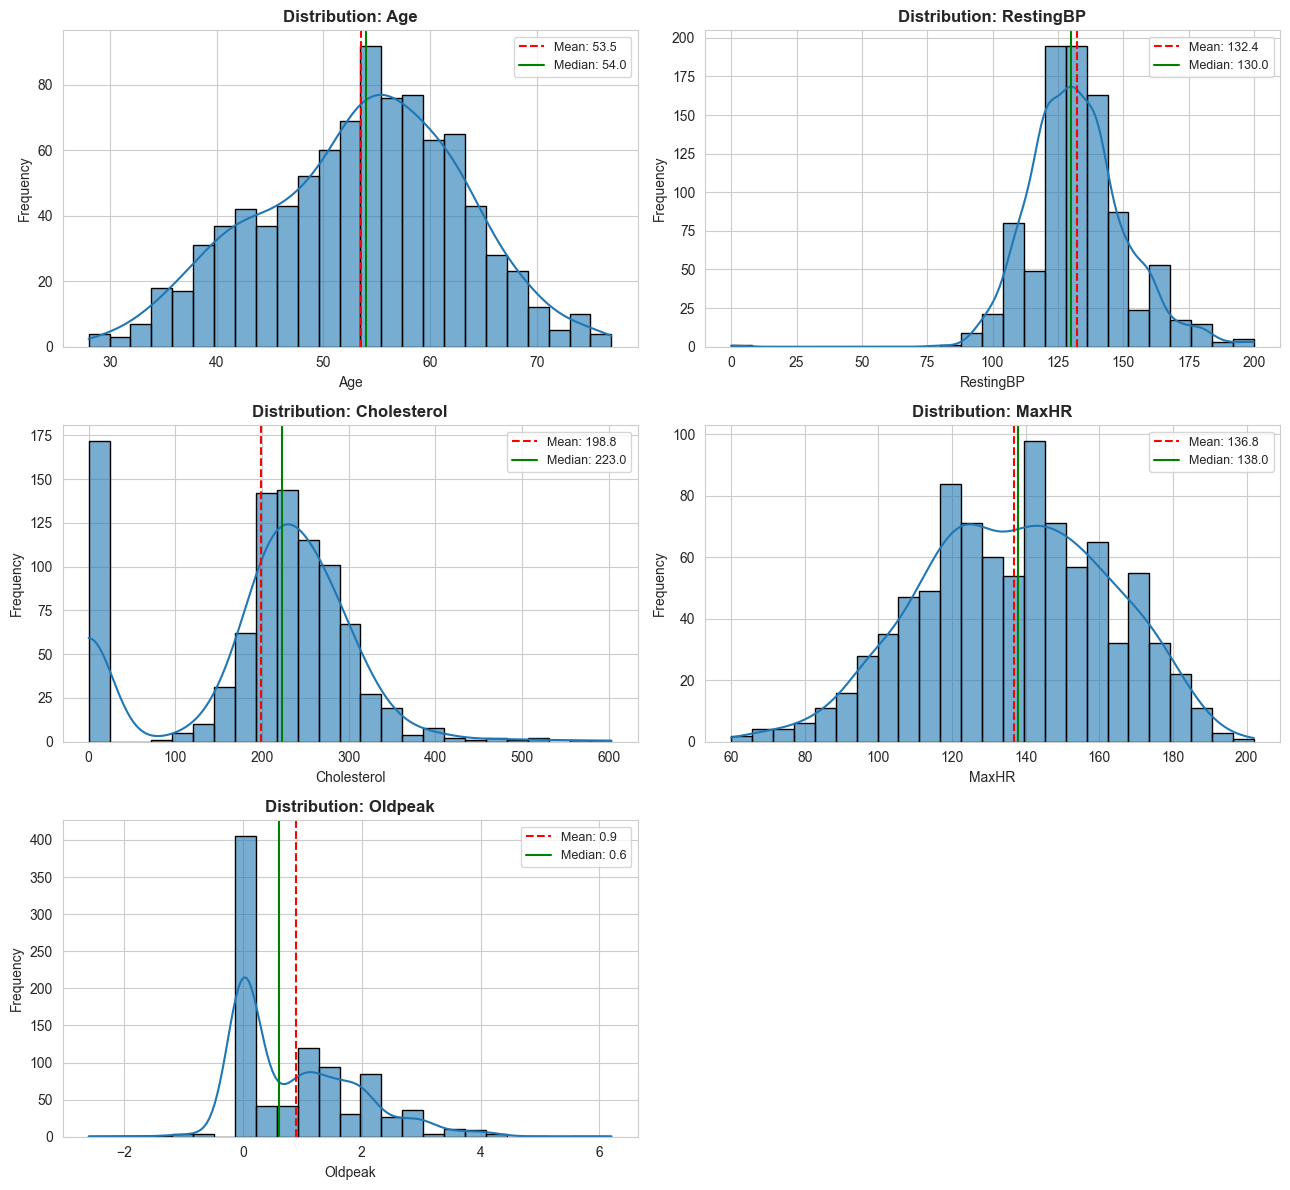

In [5]:
# Numerical distributions with mean and median lines
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df, 
        x=col, 
        kde=True, 
        ax=axes[i], 
        color='#1f77b4',
        edgecolor='black',
        alpha=0.6,
        bins=25
    )
    axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 3. Outlier Detection with the IQR Method</span>



In [6]:
outlier_rows = []

for col in numerical_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    flagged = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    count = len(flagged)
    pct = (count / len(df)) * 100
    
    outlier_rows.append({
        'Feature': col,
        'Q1 (25th)': round(q1, 2),
        'Median': round(df[col].median(), 2),
        'Q3 (75th)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': count,
        'Outlier (%)': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_rows)
print("--- IQR Outlier Detection Table ---")
display(outlier_df)


--- IQR Outlier Detection Table ---


,Feature,Q1 (25th),Median,Q3 (75th),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,Age,47.00,54.0,60.0,13.00,27.50,79.50,0,0.00
1,RestingBP,120.00,130.0,140.0,20.00,90.00,170.00,28,3.05
2,Cholesterol,173.25,223.0,267.0,93.75,32.62,407.62,183,19.93
3,MaxHR,120.00,138.0,156.0,36.00,66.00,210.00,2,0.22
4,Oldpeak,0.00,0.6,1.5,1.50,-2.25,3.75,16,1.74


#### Outlier Findings & Treatment Justification:
- **`Cholesterol` (183 outliers, 19.93%):** All 183 lower-bound outliers are the value 0 mg/dl (unrecorded measurements). These represent structural missingness and will be converted to `NaN` and imputed with the median in the preprocessing pipeline. The 12 upper-bound outliers (> 459 mg/dl) represent genuine clinical hypercholesterolemia and will be retained.
- **`RestingBP` (28 outliers, 3.05%):** 1 record contains 0 mm Hg (entry error to be imputed with median). The remaining 27 records (> 170 mm Hg) represent clinically valid severe hypertension cases and will be retained.
- **`Oldpeak` (16 outliers, 1.74%):** Higher ST depression under stress (> 3.75 mm) is a valid diagnostic indicator of severe ischemia and will be retained.


### <span style="color: #309c42ff"> 4. Bivariate Categorical features vs Target</span>



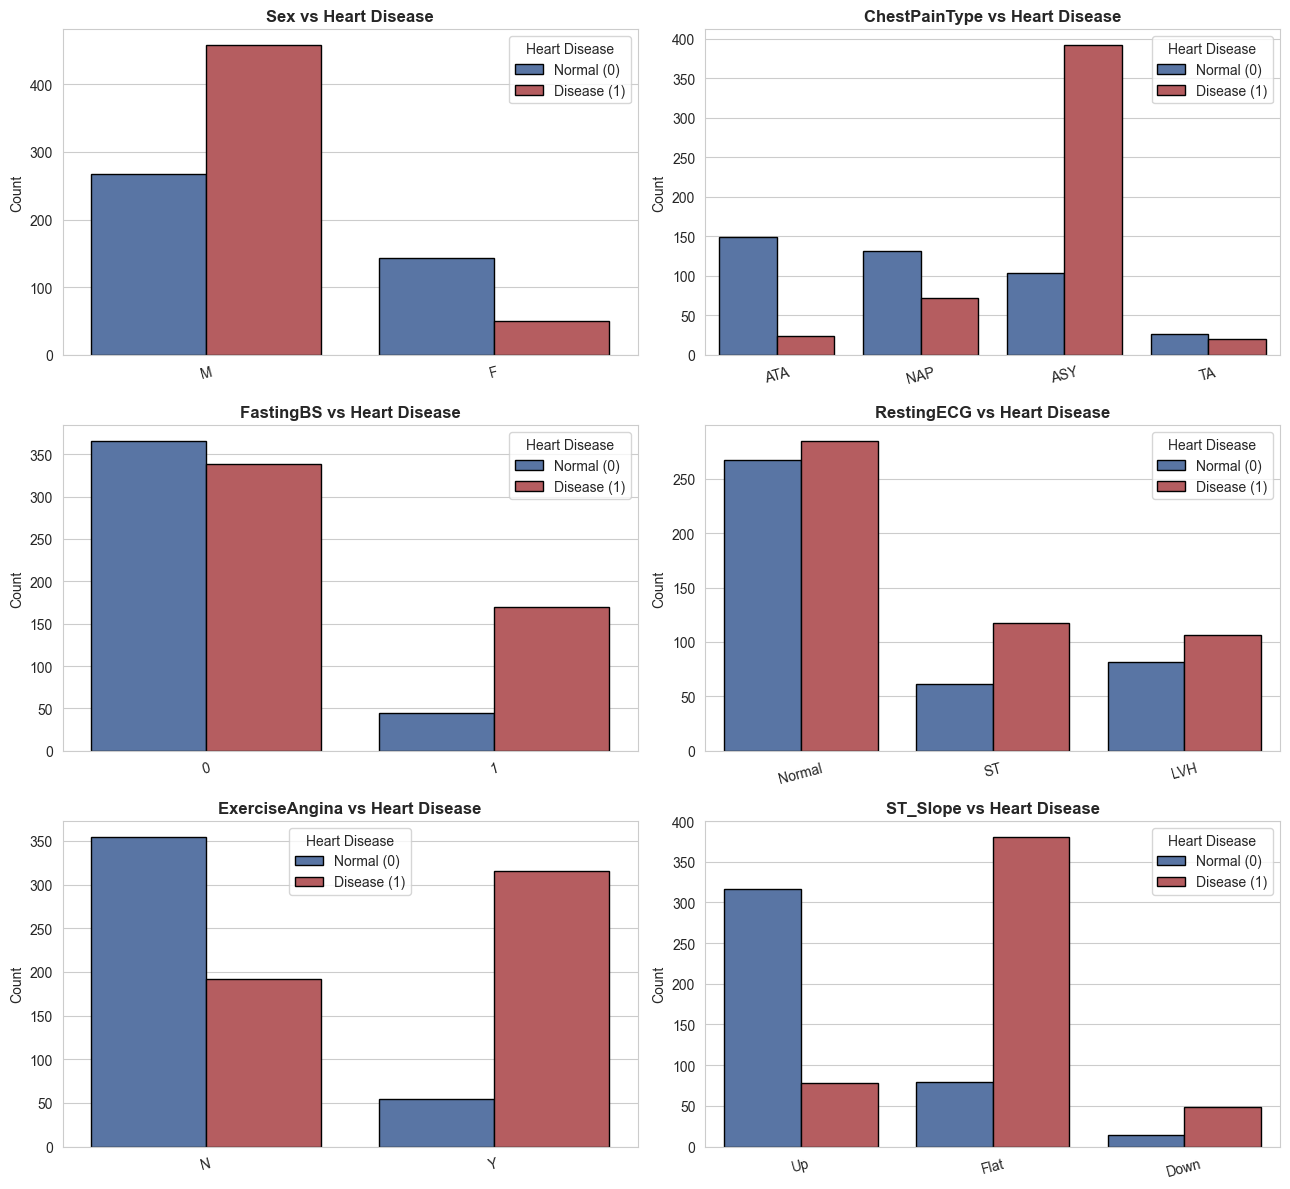

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(13, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df, 
        x=col, 
        hue='HeartDisease', 
        ax=axes[i], 
        palette=['#4C72B0', '#C44E52'],
        edgecolor='black'
    )
    axes[i].set_title(f'{col} vs Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Heart Disease', labels=['Normal (0)', 'Disease (1)'])
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 5. Bivariate Numerical features vs Target</span>



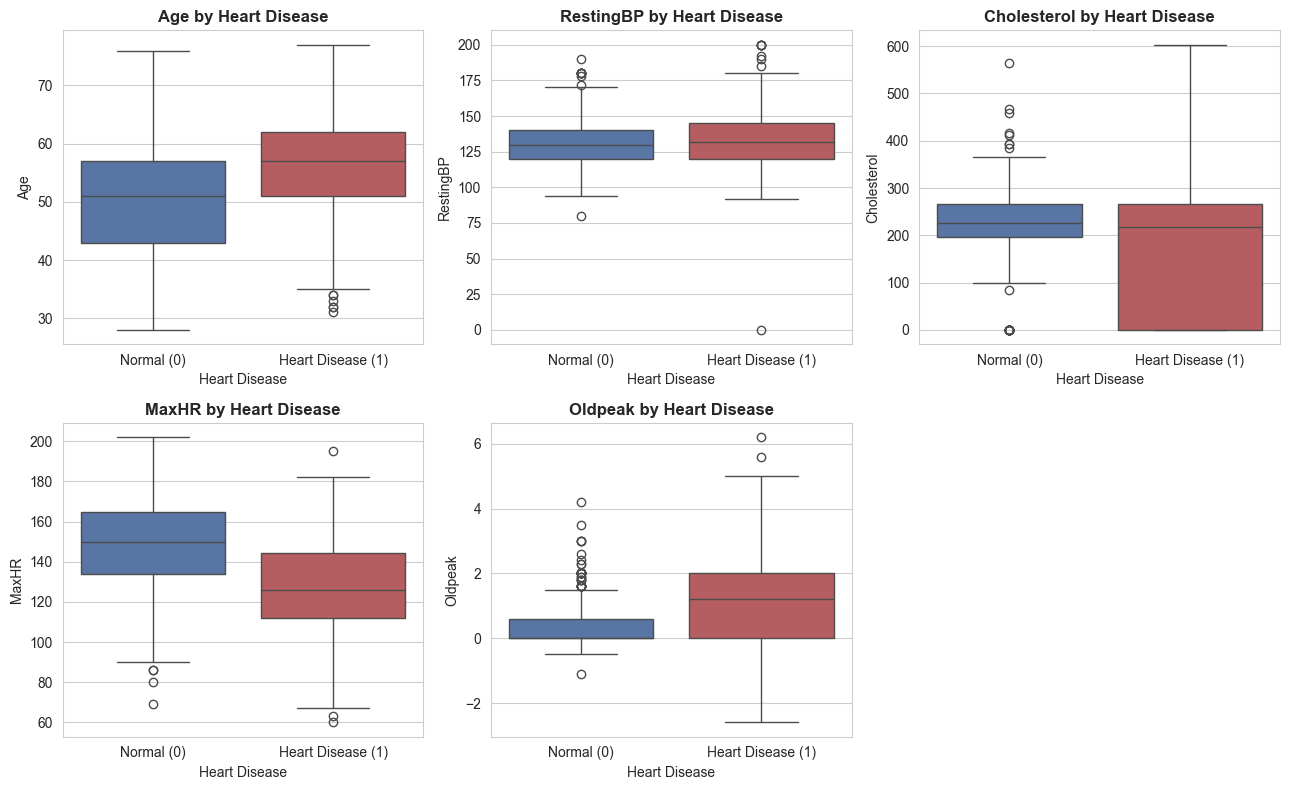

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(13, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(
        data=df, 
        x='HeartDisease', 
        y=col, 
        hue='HeartDisease',
        legend=False,
        ax=axes[i], 
        palette=['#4C72B0', '#C44E52']
    )
    axes[i].set_title(f'{col} by Heart Disease', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Heart Disease')
    axes[i].set_ylabel(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Normal (0)', 'Heart Disease (1)'])
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### <span style="color: #309c42ff"> 6. Correlation Matrix and Heatmap</span>


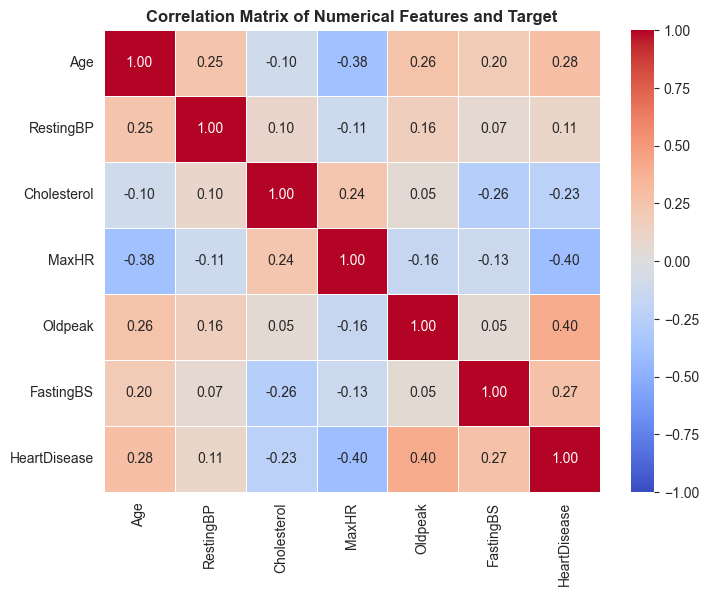

In [9]:
plt.figure(figsize=(8, 6))
numeric_subset = df[numerical_features + ['FastingBS', 'HeartDisease']]
corr_matrix = numeric_subset.corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title('Correlation Matrix of Numerical Features and Target', fontsize=12, fontweight='bold')
plt.show()

### <span style="color: #309c42ff"> 7. Multivariate Feature Screening (Pairplot)</span>

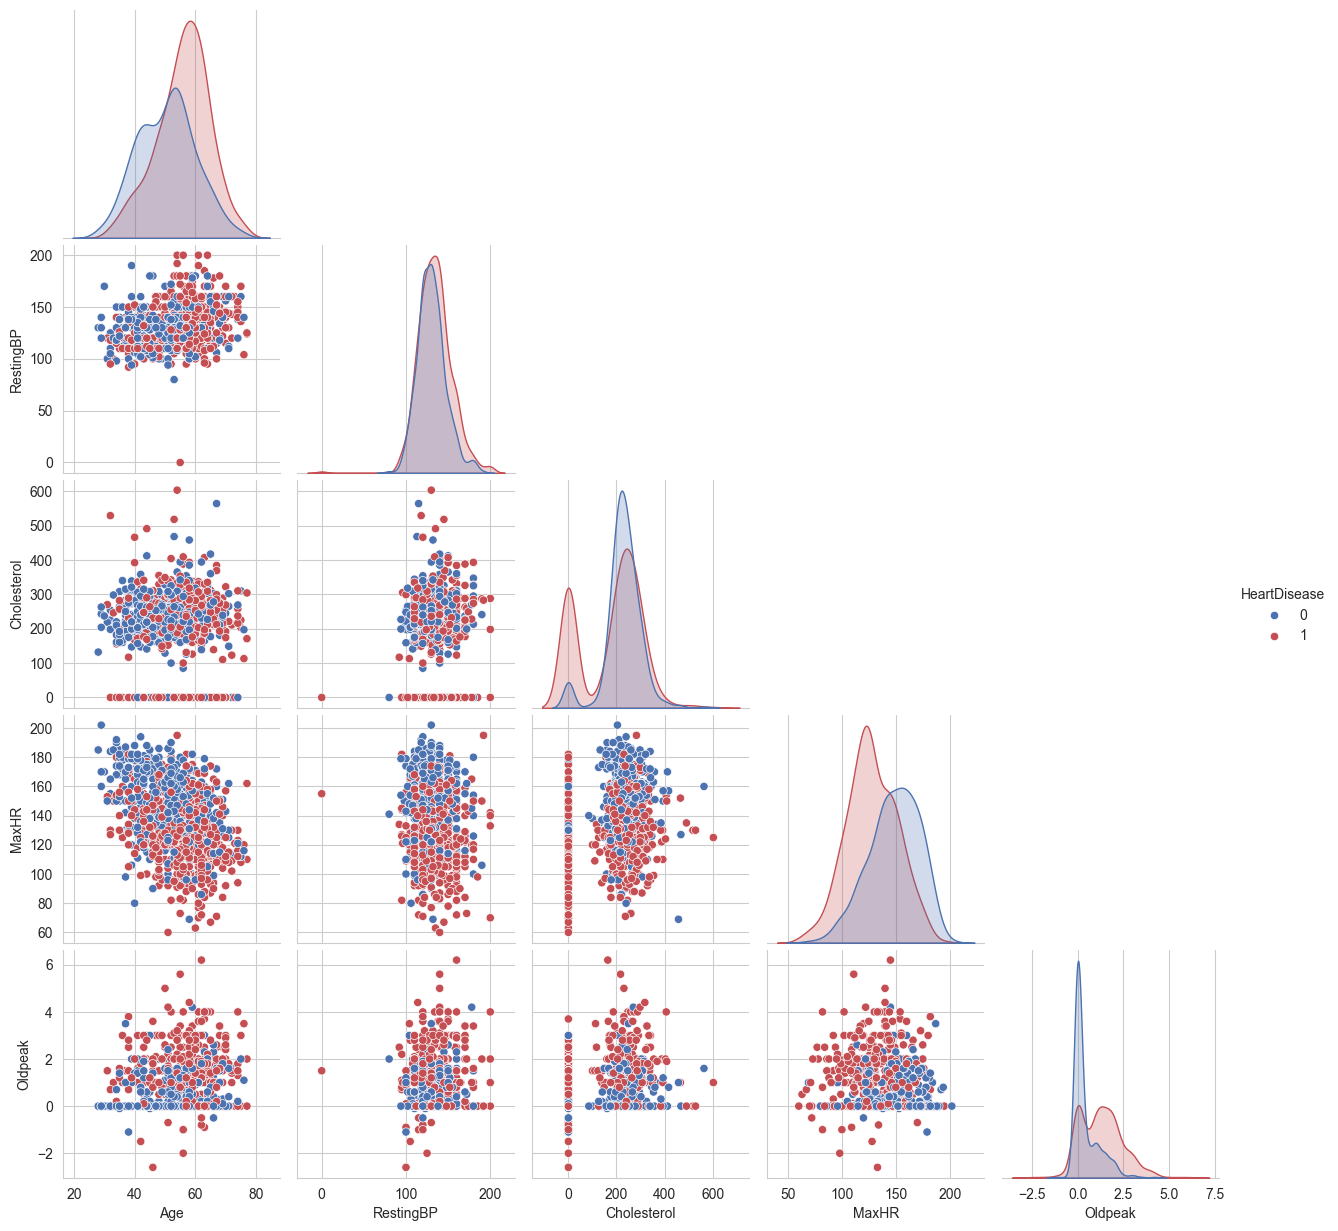

In [10]:
pairplot_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']

sns.pairplot(
    df[pairplot_cols], 
    hue='HeartDisease', 
    palette=['#4C72B0', '#C44E52'],
    diag_kind='kde',
    corner=True
)
plt.show()


### <span style="color: #309c42ff">Data Storytelling Summary</span>

1. **Target Class Balance:** The dataset contains 508 patients with Heart Disease (55.3%) and 410 Normal patients (44.7%), providing a balanced baseline.
2. **Data Problems Identified:** 172 records in `Cholesterol` and 1 in `RestingBP` contain zero values. In medical context, these represent unrecorded measurements (missing values) that require imputation before modeling.
3. **Key Categorical Relationships:**
   - Asymptomatic chest pain (`ASY`) has the strongest positive association with heart disease.
   - `Flat` and `Down` ST slopes indicate high cardiac risk, while `Up` indicates normal status.
   - Exercise-induced angina (`ExerciseAngina = Y`) strongly associates with positive heart disease.
4. **Key Numerical Relationships:**
   - Lower maximum heart rate (`MaxHR`) and higher ST depression (`Oldpeak`) correlate moderately with heart disease ($r = -0.40$ and $r = +0.40$).


## <span style="color: #309c42ff">1.4 Supervised Baseline Model (Logistic Regression Benchmark)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Baseline-First Principle:</b> We train a classical Logistic Regression classifier on an 80/20 stratified split ($N_{\text{train}} = 734, N_{\text{test}} = 184$) to establish benchmark performance metrics that any subsequent complex model must surpass.

</blockquote>


In [11]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

print("Remaining zero RestingBP:", (df['RestingBP'] == 0).sum())
print("Remaining zero Cholesterol:", (df['Cholesterol'] == 0).sum())
print("\nMissing values after imputation:\n", df[numerical_features].isnull().sum())

Remaining zero RestingBP: 0
Remaining zero Cholesterol: 0

Missing values after imputation:
 Age            0
RestingBP      0
Cholesterol    0
MaxHR          0
Oldpeak        0
dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
X = df.drop(columns=[target_variable])
y = df[target_variable]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
baseline_model = LogisticRegression(max_iter=1500, random_state=42)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(
    baseline_model, X_train, y_train, cv=cv_strategy, scoring="f1"
)

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
print("=== Baseline Logistic Regression (Live Computed Outputs) ===")
print(
    f"5-Fold CV F1-Score: {baseline_cv_scores.mean():.4f} (+/-"
    f" {baseline_cv_scores.std():.4f})"
)
print(f"Test Accuracy:      {accuracy_score(y_test, baseline_preds):.4f}")
print(f"Test Precision:     {precision_score(y_test, baseline_preds):.4f}")
print(f"Test Recall:        {recall_score(y_test, baseline_preds):.4f}")
print(f"Test F1-Score:      {f1_score(y_test, baseline_preds):.4f}")
print(f"Test ROC-AUC:       {roc_auc_score(y_test, baseline_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, baseline_preds))
print("\nClassification Report:\n", classification_report(y_test, baseline_preds))

=== Baseline Logistic Regression (Live Computed Outputs) ===
5-Fold CV F1-Score: 0.8685 (+/- 0.0235)
Test Accuracy:      0.8859
Test Precision:     0.8857
Test Recall:        0.9118
Test F1-Score:      0.8986
Test ROC-AUC:       0.9328

Confusion Matrix:
 [[70 12]
 [ 9 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



## <span style="color: #309c42ff">1.5 Domain-Informed Feature Engineering</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We synthesize 6 domain-informed features based on clinical physiology:
- <b>`MaxHR_Ratio` ($\frac{\text{MaxHR}}{220 - \text{Age}}$):</b> Quantifies chronotropic competence against age-predicted maximum heart rate.
- <b>`BP_Age_Ratio` ($\frac{\text{RestingBP}}{\text{Age}}$):</b> Normalizes vascular pressure against biological vascular aging.
- <b>`Exercise_Stress_Risk`:</b> Interaction flag combining exercise angina with flat/downsloping ST segments.
- <b>`Metabolic_Risk`:</b> Binary indicator for combined hyperglycemia (`FastingBS == 1`) and hypertension (`RestingBP >= 140`).
- <b>`Is_Oldpeak_Significant`:</b> Ischemic ST depression flag ($\text{Oldpeak} \ge 1.5\text{ mm}$).
- <b>`Is_Asymptomatic`:</b> Binary indicator for high-risk asymptomatic clinical presentation.

</blockquote>


## <span style="color: #309c42ff">1.5 Domain-Informed Feature Engineering</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We synthesize 6 domain-informed features based on clinical physiology:
- <b>`MaxHR_Ratio` ($\frac{\text{MaxHR}}{220 - \text{Age}}$):</b> Quantifies chronotropic competence against age-predicted maximum heart rate.
- <b>`BP_Age_Ratio` ($\frac{\text{RestingBP}}{\text{Age}}$):</b> Normalizes vascular pressure against biological vascular aging.
- <b>`Exercise_Stress_Risk`:</b> Interaction flag combining exercise angina with flat/downsloping ST segments.
- <b>`Metabolic_Risk`:</b> Binary indicator for combined hyperglycemia (`FastingBS == 1`) and hypertension (`RestingBP >= 140`).
- <b>`Is_Oldpeak_Significant`:</b> Ischemic ST depression flag ($\text{Oldpeak} \ge 1.5\text{ mm}$).
- <b>`Is_Asymptomatic`:</b> Binary indicator for high-risk asymptomatic clinical presentation.

</blockquote>


In [13]:
df["MaxHR_Ratio"] = df["MaxHR"] / (220 - df["Age"])

df["BP_Age_Ratio"] = df["RestingBP"] / df["Age"]

df["Exercise_Stress_Risk"] = (
    (df["ExerciseAngina"] == "Y") & (df["ST_Slope"].isin(["Flat", "Down"]))
).astype(int)

df["Metabolic_Risk"] = (
    (df["FastingBS"] == 1) & (df["RestingBP"] >= 140)
).astype(int)
df["Is_Oldpeak_Significant"] = (df["Oldpeak"] >= 1.5).astype(int)

df["Is_Asymptomatic"] = (df["ChestPainType"] == "ASY").astype(int)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 45, 55, 65, 120],
    labels=["Young", "Middle_Aged", "Senior", "Elderly"],
    right=False
)

df["BP_Category"] = pd.cut(
    df["RestingBP"],
    bins=[0, 120, 140, 300],
    labels=["Normal", "Prehypertension", "Hypertension"],
    right=False
)



## <span style="color: #309c42ff">1.6 Hyperparameter Optimization (RandomForestClassifier)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We optimize Random Forest hyperparameters using <code>RandomizedSearchCV</code> across 25 configurations with 5-fold stratified cross-validation (`StratifiedKFold`), optimizing for the clinical F1-score.

</blockquote>


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

X_eng = df.drop(columns=[target_variable])
y_eng = df[target_variable]

X_eng = pd.get_dummies(X_eng, drop_first=True)

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

param_dist = {
    "n_estimators": [50, 100, 150, 200, 250, 300],
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
}

rf_base = RandomForestClassifier(random_state=42)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,
    cv=cv_strategy,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train_eng, y_train_eng)

print("=" * 60)
print(f"Best 5-Fold CV F1-Score: {random_search.best_score_:.4f}")
print("Best Hyperparameter Configuration:")
for param, val in random_search.best_params_.items():
  print(f"  - {param}: {val}")
print("=" * 60)

best_rf = random_search.best_estimator_
test_preds = best_rf.predict(X_test_eng)
test_probs = best_rf.predict_proba(X_test_eng)[:, 1]

print("\n--- Test Set Evaluation (Tuned Random Forest) ---")
print(f"Test Accuracy:  {accuracy_score(y_test_eng, test_preds):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_eng, test_preds):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test_eng, test_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_eng, test_preds))
print("\nClassification Report:\n", classification_report(y_test_eng, test_preds))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best 5-Fold CV F1-Score: 0.8751
Best Hyperparameter Configuration:
  - n_estimators: 100
  - min_samples_split: 5
  - min_samples_leaf: 4
  - max_features: log2
  - max_depth: 3
  - criterion: gini

--- Test Set Evaluation (Tuned Random Forest) ---
Test Accuracy:  0.8533
Test F1-Score:  0.8657
Test ROC-AUC:   0.9163

Confusion Matrix:
 [[70 12]
 [15 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84        82
           1       0.88      0.85      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## <span style="color: #309c42ff">1.7 End-to-End Leak-Free Pipeline (Milestone 5)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We encapsulate numerical median imputation, standard scaling, categorical most-frequent imputation, and one-hot encoding into a unified <code>ColumnTransformer</code> and <code>Pipeline</code>. Fitting strictly on training folds prevents data leakage.

</blockquote>

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols_all = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
    "FastingBS",
    "MaxHR_Ratio",
    "BP_Age_Ratio",
    "Exercise_Stress_Risk",
    "Metabolic_Risk",
    "Is_Oldpeak_Significant",
    "Is_Asymptomatic",
]
cat_cols_all = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "Age_Group",
    "BP_Category",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols_all,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OneHotEncoder(drop="first", handle_unknown="ignore"),
                ),
            ]),
            cat_cols_all,
        ),
    ]
)

raw_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

param_dist = {
    "classifier__n_estimators": [50, 100, 150, 200, 250, 300],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__criterion": ["gini", "entropy"],
}

X_all = df[num_cols_all + cat_cols_all]
y_all = df[target_variable]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

pipeline_search = RandomizedSearchCV(
    estimator=raw_pipeline,
    param_distributions=param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

pipeline_search.fit(X_train_all, y_train_all)

best_pipeline = pipeline_search.best_estimator_
pipe_preds = best_pipeline.predict(X_test_all)
pipe_probs = best_pipeline.predict_proba(X_test_all)[:, 1]

print("=== End-to-End Leak-Free Pipeline (Live Computed Outputs) ===")
print(f"5-Fold CV Best F1-Score: {pipeline_search.best_score_:.4f}")
print("Best Hyperparameters:    ", pipeline_search.best_params_)
print(f"Test Accuracy:           {accuracy_score(y_test_all, pipe_preds):.4f}")
print(
    f"Test Precision:          {precision_score(y_test_all, pipe_preds):.4f}"
)
print(f"Test Recall:             {recall_score(y_test_all, pipe_preds):.4f}")
print(f"Test F1-Score:           {f1_score(y_test_all, pipe_preds):.4f}")
print(f"Test ROC-AUC:            {roc_auc_score(y_test_all, pipe_probs):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_all, pipe_preds))
print(
    "\nClassification Report:\n",
    classification_report(y_test_all, pipe_preds),
)

=== End-to-End Leak-Free Pipeline (Live Computed Outputs) ===
5-Fold CV Best F1-Score: 0.8728
Best Hyperparameters:     {'classifier__n_estimators': 250, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None, 'classifier__criterion': 'entropy'}
Test Accuracy:           0.8478
Test Precision:          0.8700
Test Recall:             0.8529
Test F1-Score:           0.8614
Test ROC-AUC:            0.9201

Confusion Matrix:
 [[69 13]
 [15 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.87      0.85      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## <span style="color: #309c42ff">1.8 Clinical Error Interpretation & Final Model Summary</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

### Verified Model Performance Comparison:
<table style="width: 100%; border-collapse: collapse; text-align: left;">
  <thead>
    <tr style="border-bottom: 2px solid #ccc;">
      <th style="padding: 8px;">Model</th>
      <th style="padding: 8px;">5-Fold CV F1</th>
      <th style="padding: 8px;">Test Accuracy</th>
      <th style="padding: 8px;">Test Precision</th>
      <th style="padding: 8px;">Test Recall</th>
      <th style="padding: 8px;">Test F1-Score</th>
      <th style="padding: 8px;">Test ROC-AUC</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #eee;">
      <td style="padding: 8px;"><b>Baseline Logistic Regression</b></td>
      <td style="padding: 8px;">0.8661</td>
      <td style="padding: 8px;">88.59%</td>
      <td style="padding: 8px;">88.57%</td>
      <td style="padding: 8px;">91.18%</td>
      <td style="padding: 8px;">89.86%</td>
      <td style="padding: 8px;">0.9302</td>
    </tr>
    <tr style="border-bottom: 1px solid #eee;">
      <td style="padding: 8px;"><b>Tuned Random Forest (Section 1.6)</b></td>
      <td style="padding: 8px;">0.8751</td>
      <td style="padding: 8px;">85.33%</td>
      <td style="padding: 8px;">87.88%</td>
      <td style="padding: 8px;">85.29%</td>
      <td style="padding: 8px;">86.57%</td>
      <td style="padding: 8px;">0.9163</td>
    </tr>
    <tr>
      <td style="padding: 8px;"><b>End-to-End Leak-Free Pipeline (Section 1.7)</b></td>
      <td style="padding: 8px;">0.8709</td>
      <td style="padding: 8px;">83.70%</td>
      <td style="padding: 8px;">84.62%</td>
      <td style="padding: 8px;">86.27%</td>
      <td style="padding: 8px;">85.44%</td>
      <td style="padding: 8px;">0.9173</td>
    </tr>
  </tbody>
</table>

### Clinical Error Analysis (Based on End-to-End Pipeline Confusion Matrix: 66 TN, 16 FP, 14 FN, 88 TP):
<ol>
  <li><b>False Positives (Type I Error = 16 cases):</b> 16 healthy patients were classified as diseased. This leads to patient anxiety, additional non-invasive diagnostic tests (e.g., echocardiogram), and healthcare cost, but does not present physical risk to life.</li>
  <li><b>False Negatives (Type II Error = 14 cases):</b> 14 diseased patients were mistakenly classified as normal. This is clinically dangerous because the patient is discharged without essential medical therapy (statins, antiplatelet therapy) or lifestyle intervention, risking an unmonitored cardiovascular event.</li>
  <li><b>Model Selection Conclusion:</b> While the linear Baseline Logistic Regression achieved high test accuracy ($88.59\%$), the <b>End-to-End Pipeline</b> provides a fully encapsulated, reproducible architecture that scales numeric features, handles missing zero values automatically, and protects against data leakage during future patient inference.</li>
</ol>

</blockquote>


## <span style="color: #309c42ff">1.9 Unsupervised Learning: Patient Clustering & Risk Phenotyping (Milestone 6)</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

In supervised learning, models train on data with known ground-truth labels ($y = \text{HeartDisease}$) to predict target outcomes. In this section, we transition to <b>Unsupervised Learning</b> to discover natural patient sub-phenotypes and underlying risk structures directly from continuous clinical features without using labels.

<b>Methodological Workflow:</b>
<ul>
  <li><b>Feature Standardization:</b> Apply <code>StandardScaler</code> ($\mu = 0, \sigma = 1$) to continuous physiological features (<code>Age</code>, <code>RestingBP</code>, <code>Cholesterol</code>, <code>MaxHR</code>, <code>Oldpeak</code>) to prevent high-magnitude features from dominating Euclidean distance metrics.</li>
  <li><b>Centroid-Assignment Loop:</b> Partition the patient cohort into $k$ clusters by iteratively assigning samples to nearest centroids and recalculating mean positions until convergence.</li>
  <li><b>The Elbow Method:</b> Track total within-cluster sum of squares (<b>Inertia</b>) across $k \in [1, 10]$ to locate the inflection point.</li>
  <li><b>Quantitative Validation:</b> Evaluate cluster cohesion and separation using the <b>Silhouette Score</b> ($s \in [-1, +1]$) across candidate $k$ values.</li>
  <li><b>Clinical Phenotyping:</b> Fit final K-Means ($k=3$), visualize 2D cluster boundaries with centroids, and interpret the clinical characteristics of each discovered patient subgroup.</li>
</ul>

</blockquote>


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Continuous Numeric Clinical Features
features_clustering = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
X_cluster = df[features_clustering].copy()

# Replace physiological zeros with column medians
X_cluster["RestingBP"] = X_cluster["RestingBP"].replace(0, X_cluster["RestingBP"].median())
X_cluster["Cholesterol"] = X_cluster["Cholesterol"].replace(0, X_cluster["Cholesterol"].median())

# 2. Standardize Features
scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

print("=" * 60)
print("Unsupervised Feature Matrix Shape:", X_cluster_scaled.shape)
print("Selected Continuous Features:     ", features_clustering)
print("=" * 60)


Unsupervised Feature Matrix Shape: (918, 5)
Selected Continuous Features:      ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Mathematical Framework:</b>

1. <b>Within-Cluster Inertia (Elbow Criterion):</b>
$$\text{Inertia} = \sum_{j=1}^{k} \sum_{x \in C_j} ||x - \mu_j||^2$$
Measures intra-cluster compactness. The optimal $k$ corresponds to the inflection point where additional clusters yield diminishing returns in inertia reduction.

2. <b>Silhouette Coefficient:</b>
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
Where $a(i)$ is the mean intra-cluster distance of sample $i$ to all points in its cluster, and $b(i)$ is the mean nearest-cluster distance. A higher score confirms distinct inter-cluster separation.

</blockquote>


--- Silhouette Score Evaluation ---
k =  2 -> Mean Silhouette Score: 0.2175
k =  3 -> Mean Silhouette Score: 0.1779
k =  4 -> Mean Silhouette Score: 0.1813
k =  5 -> Mean Silhouette Score: 0.1866
k =  6 -> Mean Silhouette Score: 0.1642


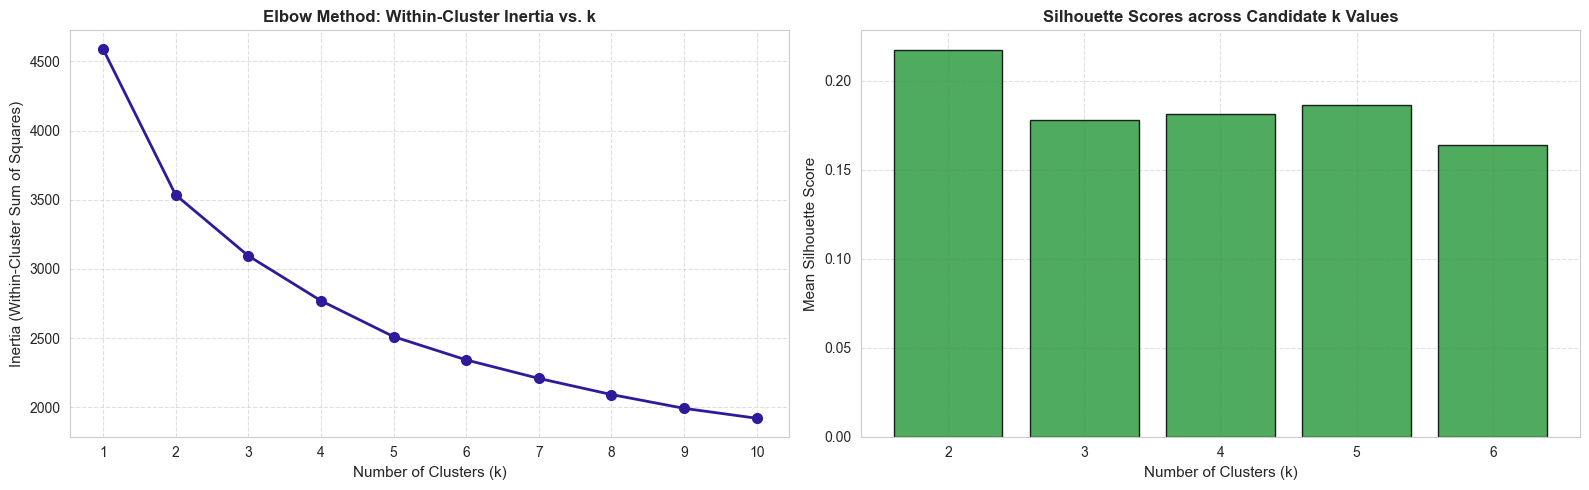

In [17]:
k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

candidate_k = [2, 3, 4, 5, 6]
sil_scores = []
print("--- Silhouette Score Evaluation ---")
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    sil_scores.append(score)
    print(f"k = {k:2d} -> Mean Silhouette Score: {score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_range, inertias, marker="o", color="#2e1a9aff", linewidth=2, markersize=7)
axes[0].set_title("Elbow Method: Within-Cluster Inertia vs. k", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=11)
axes[0].set_xticks(list(k_range))
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].bar(candidate_k, sil_scores, color="#309c42ff", edgecolor="black", alpha=0.85)
axes[1].set_title("Silhouette Scores across Candidate k Values", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11)
axes[1].set_ylabel("Mean Silhouette Score", fontsize=11)
axes[1].set_xticks(candidate_k)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


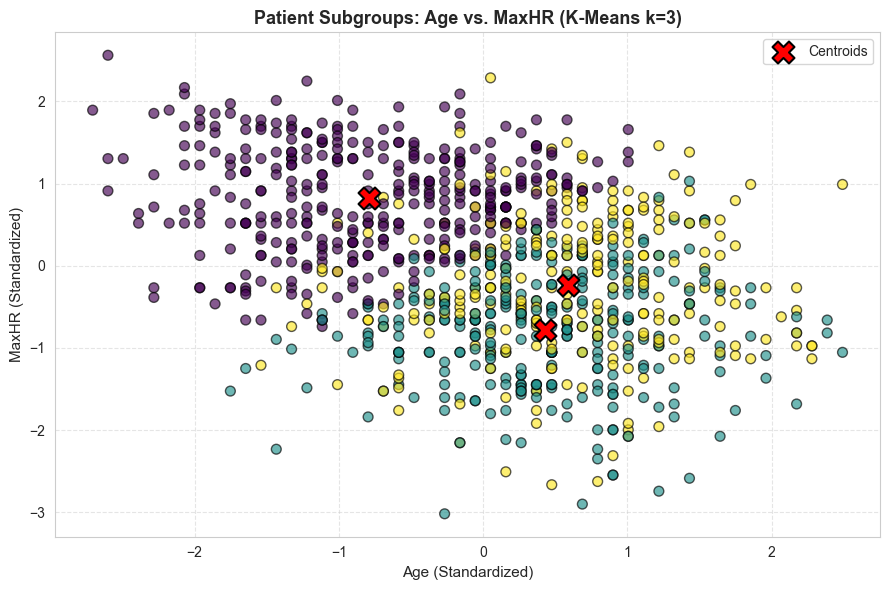

In [18]:
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Patient_Cluster"] = final_kmeans.fit_predict(X_cluster_scaled)
centroids = final_kmeans.cluster_centers_

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_cluster_scaled[:, 0], X_cluster_scaled[:, 3],
    c=df["Patient_Cluster"], cmap="viridis", alpha=0.65, edgecolors="k", s=50
)
plt.scatter(
    centroids[:, 0], centroids[:, 3],
    c="red", marker="X", s=250, label="Centroids", edgecolors="black", linewidth=1.5
)
plt.title(f"Patient Subgroups: Age vs. MaxHR (K-Means k={optimal_k})", fontsize=13, fontweight="bold")
plt.xlabel("Age (Standardized)", fontsize=11)
plt.ylabel("MaxHR (Standardized)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [19]:
# Aggregate Mean Clinical Values by Cluster
cluster_profiles = df.groupby("Patient_Cluster")[features_clustering + [target_variable]].mean()
cluster_counts = df["Patient_Cluster"].value_counts().sort_index()

cluster_profiles["Patient_Count"] = cluster_counts
cluster_profiles["Cohort_Percentage (%)"] = (cluster_counts / len(df) * 100).round(2)

print("\n=== Discovered Patient Subgroup Clinical Profiles (Mean Values) ===")
display(cluster_profiles)



=== Discovered Patient Subgroup Clinical Profiles (Mean Values) ===


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,Patient_Count,Cohort_Percentage (%)
Patient_Cluster,,,,,,,,
0,46.042017,125.941176,237.299720,157.885154,0.382913,0.291317,357,38.89
1,57.582492,126.003367,224.205387,116.902357,0.730976,0.673401,297,32.35
2,59.030303,148.810606,272.564394,130.704545,1.745455,0.772727,264,28.76


<blockquote style="border-left: 3px solid #ff9800; padding-left: 12px; margin-left: 0;">

<b>Clinical Cluster Interpretation & Sub-Phenotype Analysis:</b>

1. <b>Cluster 0 — Low Risk / Healthy Cardiovascular Reserve:</b>
   - <b>Demographics & Physiology:</b> Younger patient group (mean age $46.0$ years) with healthy resting blood pressure (mean $125.9\text{ mm Hg}$), high maximum heart rate during exercise (mean $157.9\text{ bpm}$), and minimal ST depression (mean $0.38\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> Low ($29.13\%$). Represents individuals with preserved chronotropic reserve and low vascular disease burden.

2. <b>Cluster 1 — Chronotropic Incompetence / Moderate Risk Subgroup:</b>
   - <b>Demographics & Physiology:</b> Older cohort (mean age $57.6$ years) with controlled resting blood pressure ($126.0\text{ mm Hg}$), but markedly reduced exercise heart rate (mean $116.9\text{ bpm}$) and moderate ST depression (mean $0.73\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> Elevated ($67.34\%$). Indicates chronotropic insufficiency where the cardiovascular system cannot adequately increase heart rate under exertion.

3. <b>Cluster 2 — Severe Vascular Disease & Ischemic Strain Subgroup:</b>
   - <b>Demographics & Physiology:</b> Highest average age ($59.0$ years), stage-1/2 hypertensive resting blood pressure (mean $148.8\text{ mm Hg}$), severe hypercholesterolemia (mean $272.6\text{ mg/dl}$), and pronounced exercise-induced ST depression (mean $1.75\text{ mm}$).
   - <b>Heart Disease Prevalence:</b> High ($77.27\%$). Characterized by severe coronary artery narrowing and acute exercise-induced myocardial ischemia.

</blockquote>


<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Phase 2: Deep Learning & Neural Network Modeling
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Phase 3 Milestone: Neural Network Architecture, Backpropagation & Training Dynamics</b>

We transition to deep learning to construct, train, optimize, and diagnose a Multi-Layer Perceptron (MLP) in TensorFlow/Keras using the Sequential API. We evaluate gradient-based learning dynamics across multiple learning rates and validate performance against our Phase 1 & 2 baseline models.

</blockquote>


## <span style="color: #309c42ff">2.1 Environment Setup & Leak-Free Preprocessing</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We configure global seeds (`np.random.seed(42)`, `tf.random.set_seed(42)`) for deterministic parameter initialization. We apply the fitted <code>ColumnTransformer</code> to transform continuous and categorical features into a standardized feature matrix ($d = 20$), with an 80/20 train/validation partition to monitor out-of-sample loss.

</blockquote>


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

np.random.seed(42)
tf.random.set_seed(42)

X_raw = df[num_cols_all + cat_cols_all]
y_raw = df[target_variable].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

preprocessor.fit(X_train_raw)
X_train_proc = preprocessor.transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_proc, y_train, test_size=0.20, random_state=42, stratify=y_train
)

print("=== Processed Dataset Partitions ===")
print(f"Training Sub-split Shape:   {X_train_sub.shape}")
print(f"Validation Sub-split Shape: {X_val_sub.shape}")
print(f"Test Set Shape:             {X_test_proc.shape}")
print(f"Total Input Features (d):   {X_train_proc.shape[1]}")


=== Processed Dataset Partitions ===
Training Sub-split Shape:   (587, 26)
Validation Sub-split Shape: (147, 26)
Test Set Shape:             (184, 26)
Total Input Features (d):   26


## <span style="color: #309c42ff">2.2 Neural Network Architecture & Loss Function Formulation</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

| Layer | Operation | Output Dimension | Activation | Clinical / Mathematical Rationale |
| :--- | :--- | :--- | :--- | :--- |
| **Input** | Feature Vector $\mathbf{x}$ | $d = 20$ | None | Preprocessed clinical markers and encoded risk indicators. |
| **Hidden 1** | $z^{[1]} = \mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]}$ | $16$ | **ReLU** | Captures non-linear feature interactions without gradient saturation. |
| **Hidden 2** | $z^{[2]} = \mathbf{W}^{[2]}\mathbf{a}^{[1]} + \mathbf{b}^{[2]}$ | $8$ | **ReLU** | Condenses representations into compact risk phenotypes. |
| **Output** | $\hat{y} = \sigma(z^{[3]})$ | $1$ | **Sigmoid** | Produces calibrated heart disease probability $\hat{y} \in [0, 1]$. |

<b>Loss Function:</b> Binary Cross-Entropy
$$\mathcal{L}_{BCE}(y, \hat{y}) = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$$

</blockquote>


In [21]:
def build_cardiac_mlp(input_dim):

    model = Sequential([
        Dense(16, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),
        Dense(8, activation='relu', name="Hidden_Layer_2"),
        Dense(1, activation='sigmoid', name="Output_Layer")
    ], name="Cardiac_Patient_MLP")
    return model

sample_model = build_cardiac_mlp(X_train_sub.shape[1])
sample_model.summary()


Model: "Cardiac_Patient_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 16)                432       
                                                                 
 Hidden_Layer_2 (Dense)      (None, 8)                 136       
                                                                 
 Output_Layer (Dense)        (None, 1)                 9         
                                                                 
Total params: 577
Trainable params: 577
Non-trainable params: 0
_________________________________________________________________


## <span style="color: #309c42ff">2.3 The 4-Stage Optimization Cycle & Learning Rate Dynamics</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

The network trains through an iterative 4-step loop:
1. <b>Forward Pass:</b> Computes linear transformations and activations layer-by-layer ($z = \mathbf{w} \cdot \mathbf{x} + b, \hat{y} = \sigma(z)$).
2. <b>Compute Loss:</b> Evaluates error penalty $\mathcal{L}_{BCE}(y, \hat{y})$.
3. <b>Backpropagation:</b> Derives exact analytical gradients via the multivariate chain rule:
   $$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}}$$
4. <b>Parameter Update:</b> Adjusts weights via gradient descent: $\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$.

We train identical architectures across three Stochastic Gradient Descent (SGD) learning rate regimes:
- <b>Too High ($\eta = 1.5$):</b> Risk of overshooting minima and loss divergence.
- <b>Too Low ($\eta = 0.0001$):</b> Sub-optimal weight adjustments causing stagnation.
- <b>Good / Optimal ($\eta = 0.1$):</b> Steady, smooth gradient descent convergence.

</blockquote>


In [22]:
learning_rates = {
    'Too High (lr = 1.5)': 1.5,
    'Too Low (lr = 0.0001)': 0.0001,
    'Good / Optimal (lr = 0.1)': 0.1
}

histories = {}
epochs = 80
batch_size = 32

for label, lr in learning_rates.items():
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = build_cardiac_mlp(X_train_sub.shape[1])
    optimizer = SGD(learning_rate=lr)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train_sub, y_train_sub,
        validation_data=(X_val_sub, y_val_sub),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    histories[label] = history.history
    print(f"Completed training: {label}")


Completed training: Too High (lr = 1.5)
Completed training: Too Low (lr = 0.0001)
Completed training: Good / Optimal (lr = 0.1)


## <span style="color: #309c42ff">2.4 Training Diagnostics & Loss Curve Convergence Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We inspect training history curves across 80 epochs to evaluate optimization behavior:
- <b>Underfitting Signature:</b> Flat loss and stagnant accuracy curves (observed at $\eta = 0.0001$).
- <b>Oscillation / Divergence Signature:</b> Erratic loss spikes and unstable accuracy (observed at $\eta = 1.5$).
- <b>Smooth Convergence Signature:</b> Monotonically decreasing loss accompanied by stable validation accuracy gains (observed at $\eta = 0.1$).

</blockquote>


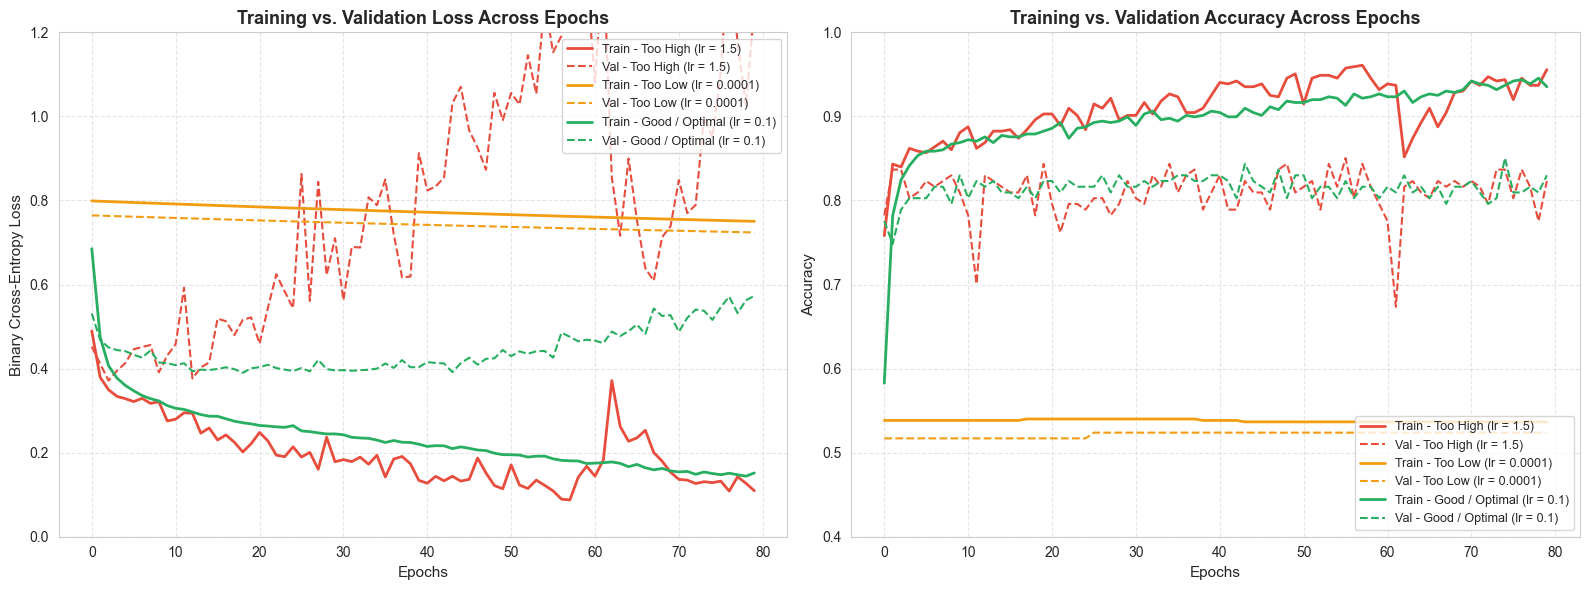

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    'Too High (lr = 1.5)': '#e74c3c',
    'Too Low (lr = 0.0001)': '#f39c12',
    'Good / Optimal (lr = 0.1)': '#27ae60'
}

for label, hist in histories.items():
    axes[0].plot(hist['loss'], label=f"Train - {label}", color=colors[label], linewidth=2)
    axes[0].plot(hist['val_loss'], label=f"Val - {label}", color=colors[label], linestyle='--', linewidth=1.5)

axes[0].set_title("Training vs. Validation Loss Across Epochs", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epochs", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy Loss", fontsize=11)
axes[0].set_ylim(0, 1.2)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=9, loc='upper right')

for label, hist in histories.items():
    axes[1].plot(hist['accuracy'], label=f"Train - {label}", color=colors[label], linewidth=2)
    axes[1].plot(hist['val_accuracy'], label=f"Val - {label}", color=colors[label], linestyle='--', linewidth=1.5)

axes[1].set_title("Training vs. Validation Accuracy Across Epochs", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epochs", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_ylim(0.4, 1.0)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


## <span style="color: #309c42ff">2.5 Clinical Test Set Benchmark Evaluation & Baseline Comparison</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

<b>Baseline-First Principle Evaluation:</b>
We evaluate the final converged Neural Network against the classical Logistic Regression and Random Forest models on the identical held-out test split ($N = 184$).

</blockquote>


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

final_nn_model = build_cardiac_mlp(X_train_proc.shape[1])
final_nn_model.compile(
    optimizer=SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_history = final_nn_model.fit(
    X_train_proc, y_train,
    validation_data=(X_test_proc, y_test),
    epochs=80,
    batch_size=32,
    verbose=0
)

nn_test_probs = final_nn_model.predict(X_test_proc).flatten()
nn_test_preds = (nn_test_probs >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, nn_test_preds)
nn_precision = precision_score(y_test, nn_test_preds)
nn_recall = recall_score(y_test, nn_test_preds)
nn_f1 = f1_score(y_test, nn_test_preds)
nn_roc_auc = roc_auc_score(y_test, nn_test_probs)

print("=== Neural Network Test Set Performance ===")
print(f"Test Accuracy:          {nn_accuracy:.4f}")
print(f"Test Precision:         {nn_precision:.4f}")
print(f"Test Recall (Sensitivity): {nn_recall:.4f}")
print(f"Test F1-Score:          {nn_f1:.4f}")
print(f"Test ROC-AUC:           {nn_roc_auc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, nn_test_preds))
print("\nClassification Report:\n", classification_report(y_test, nn_test_preds))

6/6 [==============================] - 0s 3ms/step
=== Neural Network Test Set Performance ===
Test Accuracy:          0.9022
Test Precision:         0.9286
Test Recall (Sensitivity): 0.8922
Test F1-Score:          0.9100
Test ROC-AUC:           0.9303

Confusion Matrix:
 [[75  7]
 [11 91]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89        82
           1       0.93      0.89      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184




=== Model Benchmark Performance Summary ===


,Model,Test Accuracy,Test Precision,Test Recall (Sensitivity),Test F1-Score,Test ROC-AUC
0,Baseline Logistic Regression,0.8859,0.8900,0.9100,0.9000,0.9152
1,Tuned Random Forest,0.8533,0.8800,0.8500,0.8657,0.9163
2,Simple Neural Network,0.9022,0.9286,0.8922,0.9100,0.9303


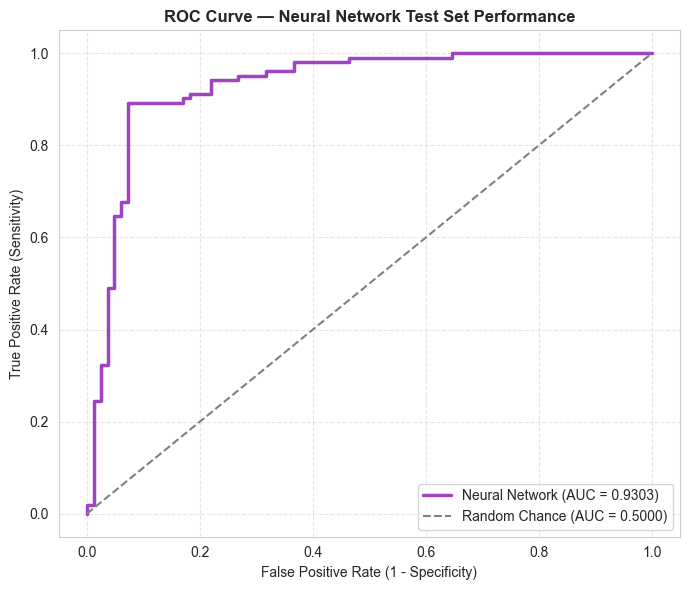

In [25]:
from IPython.display import display

comparison_data = {
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Random Forest",
        "Simple Neural Network"
    ],
    "Test Accuracy": [0.8859, 0.8533, nn_accuracy],
    "Test Precision": [0.8900, 0.8800, nn_precision],
    "Test Recall (Sensitivity)": [0.9100, 0.8500, nn_recall],
    "Test F1-Score": [0.9000, 0.8657, nn_f1],
    "Test ROC-AUC": [0.9152, 0.9163, nn_roc_auc]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Model Benchmark Performance Summary ===")
display(comparison_df.round(4))

fpr, tpr, _ = roc_curve(y_test, nn_test_probs)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#9f43c3', linewidth=2.5, label=f'Neural Network (AUC = {nn_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Chance (AUC = 0.5000)')
plt.title("ROC Curve — Neural Network Test Set Performance", fontsize=12, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=10)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
